# Projeto — Estatística Descritiva com dados de jogadores FIFA
## Fase 1

**Aluno(a):** Italo Infantini Filho
**Disciplina** Estatística Aplicada    
**Professor:** Hélio Radke Bittencourt  

Este relatório aplica técnicas de Estatística Descritiva à base de jogadores de futebol disponibilizada no repositório do curso. O notebook foi estruturado com caixas de texto e de código intercaladas, seguindo a organização geral do arquivo de exemplo `exemplo_relatorio_carros_R.ipynb`.

### Objetivos da fase 1:
1. Identificar uma variável de cada tipo: qualitativa nominal, qualitativa ordinal, quantitativa discreta e quantitativa contínua;
2. Construir tabelas de frequência para duas variáveis qualitativas;
3. Calcular medidas de posição e variabilidade para pelo menos cinco variáveis;
4. Produzir pelo menos dois gráficos para apoiar a interpretação;
5. Propor e avaliar um modelo probabilístico para uma variável da base.


## 1. Bibliotecas

Serão usados principalmente `ggplot2` e `dplyr`. O bloco abaixo instala os pacotes apenas se eles ainda não estiverem disponíveis no ambiente.


In [43]:
pacotes <- c("ggplot2", "dplyr", "scales")

novos <- pacotes[!(pacotes %in% rownames(installed.packages()))]
if (length(novos) > 0) {
  install.packages(novos, repos = "https://cloud.r-project.org")
}

invisible(lapply(pacotes, library, character.only = TRUE))
options(scipen = 999)


## 2. Leitura do banco de dados

O enunciado exige que o banco seja lido a partir do arquivo oficial no GitHub. O endereço fornecido pelo professor é a página de visualização (`blob`). Para efetivamente importar o CSV em R, utilizamos o endereço correspondente ao botão **Raw**, mantendo o arquivo no mesmo repositório e sem alterar os nomes das variáveis.

- Página oficial do arquivo:  
  <https://github.com/filipezabala/pucrs-tecnologo-bd/blob/main/dados/Anexo_Projeto_fifa_world_national_teams_versa%CC%83o_oficial%2020241.csv>
- Dicionário de variáveis:  
  <https://github.com/filipezabala/pucrs-tecnologo-bd/blob/main/dados/Anexo_Projeto_Dicionario.xlsx>

A opção `check.names = FALSE` é importante porque impede o R de transformar nomes como `international_reputation(1-5)`.


In [44]:
url_github <- paste0(
  "https://github.com/filipezabala/pucrs-tecnologo-bd/blob/main/dados/",
  "Anexo_Projeto_fifa_world_national_teams_versa%CC%83o_oficial%2020241.csv"
)

url_csv <- paste0(
  "https://github.com/filipezabala/pucrs-tecnologo-bd/raw/refs/heads/main/dados/",
  "Anexo_Projeto_fifa_world_national_teams_versa%CC%83o_oficial%2020241.csv"
)

df <- read.table(
  url_csv,
  header = TRUE,
  sep = ";",
  dec = ".",
  fileEncoding = "latin1",
  stringsAsFactors = FALSE,
  check.names = FALSE,
  quote = "",
  comment.char = ""
)

dim(df)
names(df)
head(df)


[1] 718  30

[1] "id"                            "name"                         
 [3] "full_name"                     "overall_rating"               
 [5] "value_euro"                    "wage_euro"                    
 [7] "nationality"                   "national_team"                
 [9] "club_team"                     "age"                          
[11] "height_cm"                     "weight_kgs"                   
[13] "international_reputation(1-5)" "weak_foot(1-5)"               
[15] "skill_moves(1-5)"              "club_rating"                  
[17] "Goleiro"                       "Zagueiro"                     
[19] "Meio"                          "Atacante"                     
[21] "crossing"                      "finishing"                    
[23] "heading_accuracy"              "short_passing"                
[25] "dribbling"                     "jumping"                      
[27] "strength"                      "long_shots"                   
[29] "aggression"                    "GK_reflexes"

,id,name,full_name,overall_rating,value_euro,wage_euro,nationality,national_team,club_team,age,⋯,crossing,finishing,heading_accuracy,short_passing,dribbling,jumping,strength,long_shots,aggression,GK_reflexes
,<int>,<chr>,<chr>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,158023,Messi,Lionel Andrés Messi Cuccittini,94,110500000,565000,Argentina,Argentina,FC Barcelona,31,⋯,86,95,70,92,97,68,66,94,48,8
2,153079,Aguero,Sergio Leonel Agüero del Castillo,89,64500000,300000,Argentina,Argentina,Manchester City,30,⋯,70,93,77,81,89,81,73,83,65,14
3,211110,Dybala,Paulo Bruno Exequiel Dybala,89,89000000,205000,Argentina,Argentina,Juventus,25,⋯,82,84,68,87,92,75,65,88,48,8
4,201399,Icardi,Mauro Emanuel Icardi Rivero,87,64500000,130000,Argentina,Argentina,Inter,26,⋯,46,91,91,73,77,94,76,70,56,9
5,226226,Lo Celso,Giovani Lo Celso,82,30000000,83000,Argentina,Argentina,Real Betis,22,⋯,75,77,59,82,84,64,69,76,65,14
6,199667,Funes Mori,José Ramiro Funes Mori,77,8500000,28000,Argentina,Argentina,Villarreal CF,28,⋯,66,40,79,70,63,77,78,56,83,7


### 2.1 Verificação inicial

A base contém **718 jogadores e 30 variáveis**. Na versão disponibilizada não foram identificados valores ausentes, IDs repetidos ou linhas duplicadas. Mesmo assim, o código abaixo faz essas verificações de forma reprodutível.


In [45]:
cat("Número de linhas:", nrow(df), "\n")
cat("Número de colunas:", ncol(df), "\n")
cat("Células com NA:", sum(is.na(df)), "\n")
cat("IDs duplicados:", sum(duplicated(df$id)), "\n")
cat("Linhas duplicadas:", sum(duplicated(df)), "\n")

str(df)

stopifnot(nrow(df) == 718)
stopifnot(ncol(df) == 30)
stopifnot(sum(is.na(df)) == 0)


Número de linhas: 718 
Número de colunas: 30 
Células com NA: 0 
IDs duplicados: 0 
Linhas duplicadas: 0 
'data.frame':	718 obs. of  30 variables:
 $ id                           : int  158023 153079 211110 201399 226226 199667 212616 216816 183892 231478 ...
 $ name                         : chr  "Messi" "Aguero" "Dybala" "Icardi" ...
 $ full_name                    : chr  "Lionel Andrés Messi Cuccittini" "Sergio Leonel Agüero del Castillo" "Paulo Bruno Exequiel Dybala" "Mauro Emanuel Icardi Rivero" ...
 $ overall_rating               : int  94 89 89 87 82 77 77 78 79 79 ...
 $ value_euro                   : int  110500000 64500000 89000000 64500000 30000000 8500000 12000000 15000000 8500000 18000000 ...
 $ wage_euro                    : int  565000 300000 205000 130000 83000 28000 27000 53000 19000 54000 ...
 $ nationality                  : chr  "Argentina" "Argentina" "Argentina" "Argentina" ...
 $ national_team                : chr  "Argentina" "Argentina" "Argentina" "Argentina" 

## 3. Classificação dos tipos de variáveis

Com base no dicionário fornecido:

| Tipo | Variável escolhida | Justificativa |
|---|---|---|
| **Qualitativa nominal** | `nationality` | Representa categorias de nacionalidade sem ordem natural entre elas. |
| **Qualitativa ordinal** | `international_reputation(1-5)` | O dicionário define uma escala ordenada de 1 (pior) a 5 (melhor). |
| **Quantitativa discreta** | `overall_rating` | É um escore geral de 0 a 100 registrado em valores inteiros. |
| **Quantitativa contínua** | `weight_kgs` | Peso é uma medida em escala contínua; no banco, os valores aparecem arredondados para quilogramas inteiros. |

A distinção entre a natureza da variável e a forma como ela foi registrada é importante. Por exemplo, `weight_kgs` é conceitualmente contínua, mesmo que a base apresente somente números inteiros.


## 4. Tabelas de frequência

Serão analisadas duas variáveis qualitativas:

1. `nationality` — qualitativa nominal;
2. `international_reputation(1-5)` — qualitativa ordinal.

Para a variável nominal, a tabela apresenta frequência absoluta e percentual. Para a variável ordinal, também faz sentido apresentar o percentual acumulado, pois as categorias possuem ordem.


### 4.1 Frequências de `nationality`


In [46]:
tab_nat <- sort(table(df$nationality), decreasing = TRUE)

freq_nationality <- data.frame(
  nationality = names(tab_nat),
  Frequencia = as.vector(tab_nat),
  Percentual = round(100 * as.vector(tab_nat) / nrow(df), 2),
  check.names = FALSE
)

freq_nationality


nationality,Frequencia,Percentual
<chr>,<int>,<dbl>
Brazil,23,3.20
Denmark,23,3.20
England,23,3.20
France,23,3.20
Germany,23,3.20
Netherlands,23,3.20
Scotland,23,3.20
Spain,23,3.20
United States,23,3.20


**Resultado na base disponibilizada**

| nationality | Frequência | Percentual (%) |
| --- | --- | --- |
| Brazil | 23 | 3,20 |
| Denmark | 23 | 3,20 |
| Germany | 23 | 3,20 |
| France | 23 | 3,20 |
| England | 23 | 3,20 |
| Netherlands | 23 | 3,20 |
| Scotland | 23 | 3,20 |
| United States | 23 | 3,20 |
| Spain | 23 | 3,20 |
| Italy | 22 | 3,06 |
| Norway | 22 | 3,06 |
| Poland | 21 | 2,92 |
| Wales | 21 | 2,92 |
| Greece | 21 | 2,92 |
| Republic of Ireland | 21 | 2,92 |
| Turkey | 21 | 2,92 |
| Czech Republic | 20 | 2,79 |
| Sweden | 20 | 2,79 |
| Belgium | 19 | 2,65 |
| Canada | 19 | 2,65 |
| Finland | 19 | 2,65 |
| Cameroon | 17 | 2,37 |
| Argentina | 17 | 2,37 |
| Switzerland | 16 | 2,23 |
| Austria | 16 | 2,23 |
| Uruguay | 15 | 2,09 |
| Portugal | 15 | 2,09 |
| Ivory Coast | 14 | 1,95 |
| Slovenia | 14 | 1,95 |
| Russia | 13 | 1,81 |
| Venezuela | 13 | 1,81 |
| Iceland | 13 | 1,81 |
| Australia | 13 | 1,81 |
| Colombia | 12 | 1,67 |
| Romania | 11 | 1,53 |
| Mexico | 10 | 1,39 |
| Chile | 10 | 1,39 |
| Hungary | 8 | 1,11 |
| New Zealand | 7 | 0,97 |
| Egypt | 7 | 0,97 |
| Peru | 7 | 0,97 |
| South Africa | 6 | 0,84 |
| Ecuador | 6 | 0,84 |
| Bulgaria | 3 | 0,42 |
| Paraguay | 2 | 0,28 |

**Interpretação.** Há **45 nacionalidades** representadas. Brasil, Dinamarca, Alemanha, França, Inglaterra, Holanda, Escócia, Estados Unidos e Espanha aparecem com 23 jogadores cada, correspondendo a aproximadamente **3,20%** da base por nacionalidade. A distribuição é relativamente pulverizada, sem uma única nacionalidade dominando a amostra.


### 4.2 Frequências de `international_reputation(1-5)`


In [47]:
tab_rep <- table(df[["international_reputation(1-5)"]])

freq_reputacao <- data.frame(
  `international_reputation(1-5)` = as.numeric(names(tab_rep)),
  Frequencia = as.vector(tab_rep),
  Percentual = round(100 * as.vector(tab_rep) / nrow(df), 2),
  Percentual_acumulado = round(100 * cumsum(as.vector(tab_rep)) / nrow(df), 2),
  check.names = FALSE
)

freq_reputacao


international_reputation(1-5),Frequencia,Percentual,Percentual_acumulado
<dbl>,<int>,<dbl>,<dbl>
1,402,55.99,55.99
2,183,25.49,81.48
3,104,14.48,95.96
4,24,3.34,99.30
5,5,0.70,100.00


**Resultado na base disponibilizada**

| international_reputation(1-5) | Frequência | Percentual (%) | Percentual acumulado (%) |
| --- | --- | --- | --- |
| 1,00 | 402,00 | 55,99 | 55,99 |
| 2,00 | 183,00 | 25,49 | 81,48 |
| 3,00 | 104,00 | 14,48 | 95,96 |
| 4,00 | 24,00 | 3,34 | 99,30 |
| 5,00 | 5,00 | 0,70 | 100,00 |

**Interpretação.** A categoria 1 concentra **55,99%** dos jogadores e as categorias 1 e 2, juntas, representam **81,48%** da base. Apenas **4,04%** dos jogadores possuem reputação internacional 4 ou 5. Assim, a distribuição é fortemente concentrada nos níveis mais baixos da escala.


## 5. Medidas de posição e variabilidade

Foram escolhidas cinco variáveis quantitativas:

- `overall_rating`;
- `value_euro`;
- `wage_euro`;
- `age`;
- `weight_kgs`.

Serão calculados: tamanho da amostra, média, mediana, primeiro e terceiro quartis, mínimo, máximo, desvio-padrão, variância, intervalo interquartil (IQR) e coeficiente de variação (CV).


In [48]:
variaveis <- c(
  "overall_rating",
  "value_euro",
  "wage_euro",
  "age",
  "weight_kgs"
)

estatisticas <- do.call(
  rbind,
  lapply(variaveis, function(v) {
    x <- df[[v]]
    data.frame(
      Variavel = v,
      n = sum(!is.na(x)),
      Media = mean(x, na.rm = TRUE),
      Mediana = median(x, na.rm = TRUE),
      Q1 = as.numeric(quantile(x, 0.25, na.rm = TRUE)),
      Q3 = as.numeric(quantile(x, 0.75, na.rm = TRUE)),
      Minimo = min(x, na.rm = TRUE),
      Maximo = max(x, na.rm = TRUE),
      Desvio_padrao = sd(x, na.rm = TRUE),
      Variancia = var(x, na.rm = TRUE),
      IQR = IQR(x, na.rm = TRUE),
      CV_percentual = 100 * sd(x, na.rm = TRUE) / mean(x, na.rm = TRUE)
    )
  })
)

estatisticas_exibicao <- estatisticas
colunas_numericas <- sapply(estatisticas_exibicao, is.numeric)
estatisticas_exibicao[colunas_numericas] <- lapply(
  estatisticas_exibicao[colunas_numericas],
  round,
  digits = 2
)

estatisticas_exibicao


Variavel,n,Media,Mediana,Q1,Q3,Minimo,Maximo,Desvio_padrao,Variancia,IQR,CV_percentual
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
overall_rating,718,76.46,76,72,80,58,94,6.02,36.22,8,7.87
value_euro,718,13897694.99,8000000,3325000,17000000,230000,110500000,16917513.81,286202273445191.00,13675000,121.73
wage_euro,718,49559.89,27000,10000,59000,1000,565000,65224.91,4254288598.03,49000,131.61
age,718,26.57,26,24,29,18,37,3.59,12.88,5,13.51
weight_kgs,718,77.67,77,73,82,59,100,7.30,53.27,9,9.40


**Resultado na base disponibilizada**

| Variável | n | Média | Mediana | Q1 | Q3 | Mínimo | Máximo | Desvio-padrão | Variância | IQR | CV (%) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| overall_rating | 718 | 76,46 | 76,00 | 72,00 | 80,00 | 58,00 | 94,00 | 6,02 | 36,22 | 8,00 | 7,87 |
| value_euro | 718 | 13.897.694,99 | 8.000.000,00 | 3.325.000,00 | 17.000.000,00 | 230.000,00 | 110.500.000,00 | 16.917.513,81 | 286.202.273.445.191,06 | 13.675.000,00 | 121,73 |
| wage_euro | 718 | 49559,89 | 27000,00 | 10000,00 | 59000,00 | 1000,00 | 565.000,00 | 65224,91 | 4.254.288.598,03 | 49000,00 | 131,61 |
| age | 718 | 26,57 | 26,00 | 24,00 | 29,00 | 18,00 | 37,00 | 3,59 | 12,88 | 5,00 | 13,51 |
| weight_kgs | 718 | 77,67 | 77,00 | 73,00 | 82,00 | 59,00 | 100,00 | 7,30 | 53,27 | 9,00 | 9,40 |

### Interpretação das medidas

- `overall_rating`: média de **76,46** e mediana **76**, com desvio-padrão de **6,02**. O CV de aproximadamente **7,87%** indica dispersão relativamente baixa em torno da média.
- `value_euro`: média de aproximadamente **€ 13,90 milhões**, enquanto a mediana é **€ 8,00 milhões**. A média bem maior que a mediana e o CV de **121,73%** indicam forte assimetria à direita, causada por jogadores de valor muito elevado.
- `wage_euro`: média de aproximadamente **€ 49.559,89** e mediana de **€ 27.000,00**. O CV de **131,61%** mostra heterogeneidade ainda maior e forte assimetria à direita.
- `age`: média de **26,57 anos**, mediana **26 anos** e IQR de **5 anos**, mostrando concentração de metade central dos jogadores entre **24 e 29 anos**.
- `weight_kgs`: média de **77,67 kg**, mediana **77 kg** e desvio-padrão de **7,30 kg**.


## 6. Visualizações

Os gráficos a seguir buscam responder perguntas específicas da base, e não apenas reproduzir distribuições isoladas.


### 6.1 Gráfico 1 — Seleções com maior `overall_rating` médio

Para evitar que seleções com pouquíssimos jogadores sejam comparadas diretamente com grupos maiores, o gráfico considera apenas seleções com pelo menos 10 jogadores na base e mostra as 10 maiores médias.


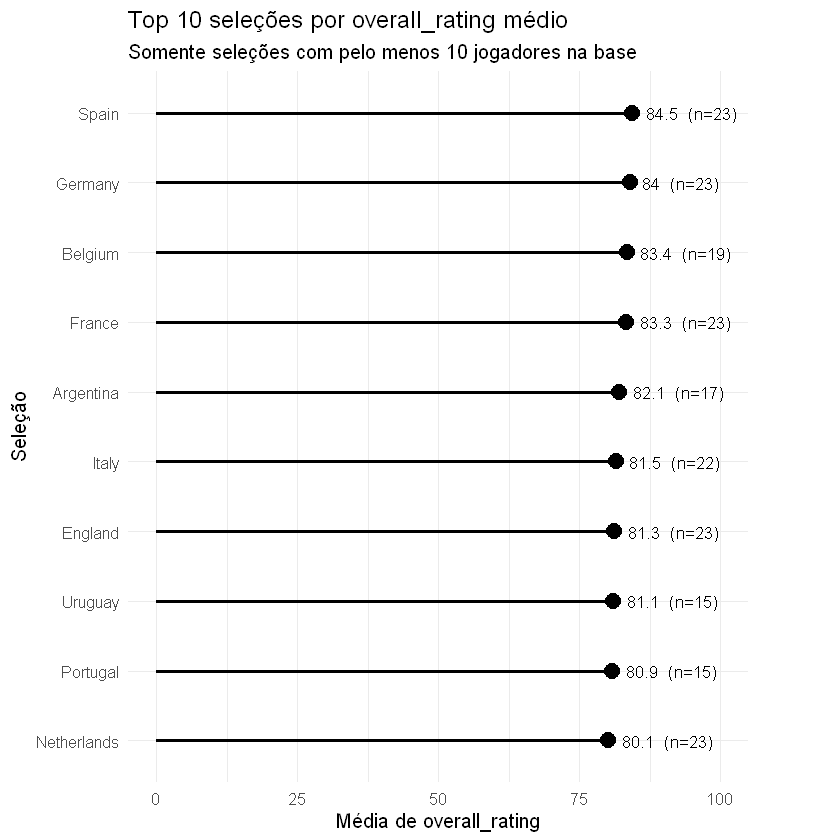

In [49]:
resumo_selecao <- df %>%
  group_by(national_team) %>%
  summarise(
    n = n(),
    media_overall = mean(overall_rating, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  filter(n >= 10) %>%
  arrange(desc(media_overall)) %>%
  slice_head(n = 10)

ggplot(
  resumo_selecao,
  aes(x = reorder(national_team, media_overall), y = media_overall)
) +
  geom_segment(
    aes(xend = reorder(national_team, media_overall), y = 0, yend = media_overall),
    linewidth = 0.9
  ) +
  geom_point(size = 4) +
  geom_text(
    aes(label = paste0(round(media_overall, 1), "  (n=", n, ")")),
    hjust = -0.15,
    size = 3.5
  ) +
  coord_flip(clip = "off") +
  scale_y_continuous(limits = c(0, 100)) +
  labs(
    title = "Top 10 seleções por overall_rating médio",
    subtitle = "Somente seleções com pelo menos 10 jogadores na base",
    x = "Seleção",
    y = "Média de overall_rating"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.margin = margin(5.5, 55, 5.5, 5.5))


**Valores que sustentam o gráfico**

| Seleção | n | Média de overall_rating |
| --- | --- | --- |
| Spain | 23 | 84,48 |
| Germany | 23 | 84,04 |
| Belgium | 19 | 83,42 |
| France | 23 | 83,30 |
| Argentina | 17 | 82,12 |
| Italy | 22 | 81,50 |
| England | 23 | 81,26 |
| Uruguay | 15 | 81,07 |
| Portugal | 15 | 80,87 |
| Netherlands | 23 | 80,13 |

**Interpretação.** Entre as seleções com pelo menos 10 jogadores, **Espanha** apresenta a maior média de `overall_rating` (**84,48**), seguida de **Alemanha** (**84,04**), **Bélgica** (**83,42**) e **França** (**83,30**). O resultado resume a qualidade média dos jogadores presentes nesta base específica; não deve ser interpretado como um ranking oficial de seleções.


### 6.2 Gráfico 2 — Relação entre avaliação e valor de mercado

O eixo de `value_euro` é mostrado em escala logarítmica porque os valores de mercado são muito assimétricos. O tamanho dos pontos representa `international_reputation(1-5)` e a cor representa a idade.


`geom_smooth()` using formula = 'y ~ x'
Warning message:
"The following aesthetics were dropped during statistical transformation: size
and colour.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?"


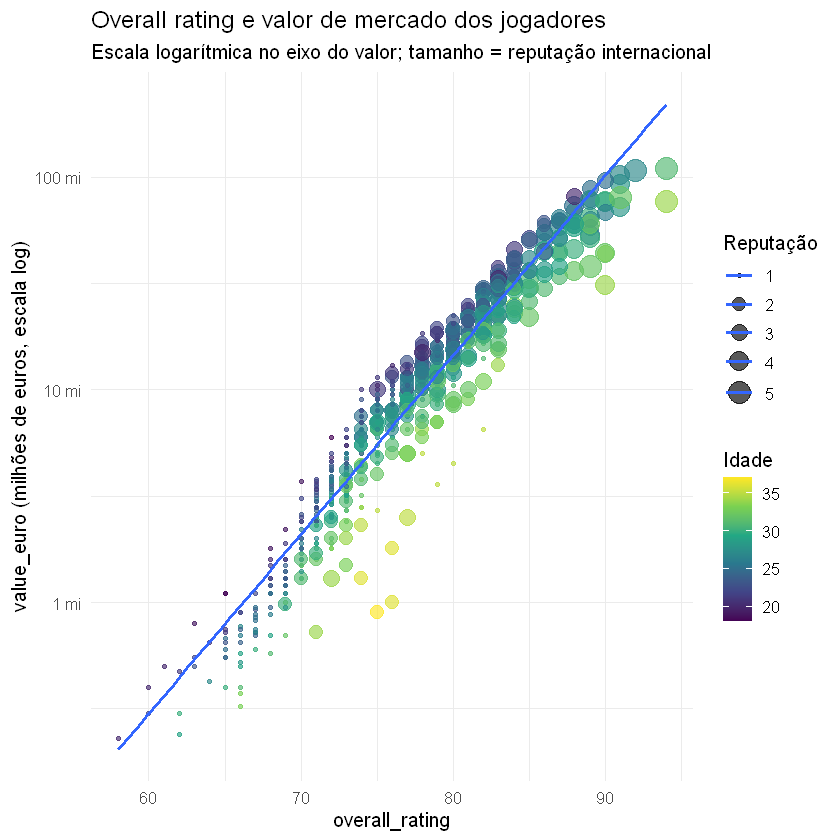

In [50]:
ggplot(
  df,
  aes(
    x = overall_rating,
    y = value_euro,
    size = `international_reputation(1-5)`,
    color = age
  )
) +
  geom_point(alpha = 0.65) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 0.9) +
  scale_y_log10(
    labels = scales::label_number(
      scale = 1e-6,
      suffix = " mi",
      decimal.mark = ","
    )
  ) +
  scale_color_viridis_c() +
  labs(
    title = "Overall rating e valor de mercado dos jogadores",
    subtitle = "Escala logarítmica no eixo do valor; tamanho = reputação internacional",
    x = "overall_rating",
    y = "value_euro (milhões de euros, escala log)",
    color = "Idade",
    size = "Reputação"
  ) +
  theme_minimal(base_size = 12)


In [51]:
cor.test(
  df$overall_rating,
  log10(df$value_euro),
  method = "pearson"
)



	Pearson's product-moment correlation

data:  df$overall_rating and log10(df$value_euro)
t = 88.827, df = 716, p-value < 0.00000000000000022
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.9509533 0.9631878
sample estimates:
      cor 
0.9574991 


**Interpretação.** O gráfico evidencia uma associação positiva muito forte: jogadores com maior `overall_rating` tendem a possuir maior `value_euro`. A correlação de Pearson entre `overall_rating` e `log10(value_euro)` é aproximadamente **r = 0.957**. A escala logarítmica é importante porque impede que poucos jogadores extremamente valorizados comprimam visualmente o restante dos pontos.


## 7. Modelo probabilístico

### 7.1 Variável escolhida: `weight_kgs`

O peso é positivo e conceitualmente contínuo. Como a distribuição observada apresenta leve assimetria à direita e não admite valores negativos, será testado um modelo **Lognormal**.

Se \(X\) representa `weight_kgs` e

\[
X \sim \text{Lognormal}(\mu,\sigma),
\]

então

\[
\log(X) \sim N(\mu,\sigma^2).
\]

Os parâmetros serão estimados diretamente dos dados:

\[
\hat{\mu} = \overline{\log(X)}
\]

e

\[
\hat{\sigma} =
\sqrt{\frac{1}{n}\sum_{i=1}^{n}(\log x_i-\hat{\mu})^2}.
\]

O uso do divisor \(n\) no desvio do log corresponde à estimativa de máxima verossimilhança para o parâmetro do modelo.


In [52]:
peso <- df$weight_kgs

meanlog <- mean(log(peso))
sdlog <- sqrt(mean((log(peso) - meanlog)^2))

cat("meanlog =", round(meanlog, 5), "\n")
cat("sdlog   =", round(sdlog, 5), "\n")
cat("Mediana teórica =", round(exp(meanlog), 2), "kg\n")


meanlog = 4.34813 
sdlog   = 0.09366 
Mediana teórica = 77.33 kg


Na base, as estimativas são:

- \(\hat{\mu} pprox\) **4.34813**;
- \(\hat{\sigma} pprox\) **0.09366**;
- mediana teórica \(e^{\hat{\mu}}\) ≈ **77.33 kg**.

A mediana observada é **77 kg**, muito próxima da mediana prevista pelo modelo.


### 7.2 Histograma com densidade Lognormal ajustada

O histograma é apresentado como densidade (`probability = TRUE`) para permitir a sobreposição da densidade teórica Lognormal.


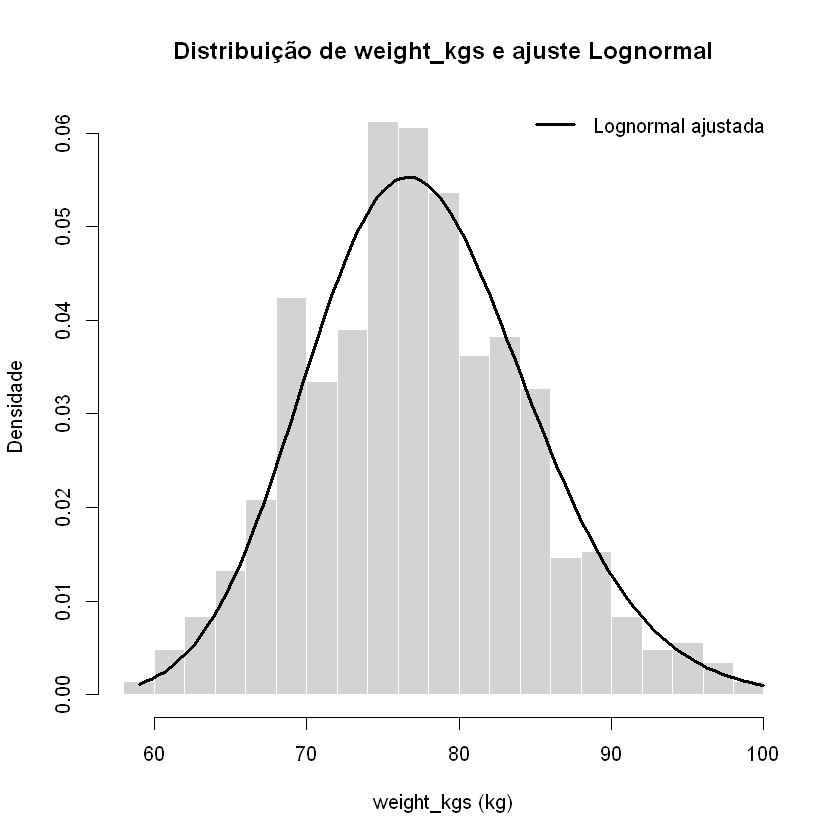

In [53]:
hist(
  peso,
  probability = TRUE,
  breaks = "FD",
  main = "Distribuição de weight_kgs e ajuste Lognormal",
  xlab = "weight_kgs (kg)",
  ylab = "Densidade",
  border = "white"
)

curve(
  dlnorm(x, meanlog = meanlog, sdlog = sdlog),
  from = min(peso),
  to = max(peso),
  add = TRUE,
  lwd = 3
)

legend(
  "topright",
  legend = "Lognormal ajustada",
  lwd = 3,
  bty = "n"
)


### 7.3 Comparação de quantis observados e teóricos


In [54]:
probabilidades <- c(0.05, 0.25, 0.50, 0.75, 0.95)

comparacao_quantis <- data.frame(
  Probabilidade = probabilidades,
  Quantil_observado = as.numeric(
    quantile(peso, probs = probabilidades, names = FALSE)
  ),
  Quantil_lognormal = qlnorm(
    probabilidades,
    meanlog = meanlog,
    sdlog = sdlog
  )
)

round(comparacao_quantis, 2)


Probabilidade,Quantil_observado,Quantil_lognormal
<dbl>,<dbl>,<dbl>
0.05,66,66.29
0.25,73,72.60
0.50,77,77.33
0.75,82,82.38
0.95,90,90.21


**Resultado na base disponibilizada**

| Probabilidade | Quantil observado (kg) | Quantil Lognormal (kg) |
| --- | --- | --- |
| 5% | 66,00 | 66,29 |
| 25% | 73,00 | 72,60 |
| 50% | 77,00 | 77,33 |
| 75% | 82,00 | 82,38 |
| 95% | 90,00 | 90,21 |

Os quantis teóricos ficam muito próximos dos quantis empíricos em diferentes regiões da distribuição. Por exemplo, o percentil 5 é aproximadamente **66,29 kg** no modelo e **66 kg** nos dados; o percentil 95 é aproximadamente **90,21 kg** no modelo e **90 kg** nos dados.


### 7.4 Comparação adicional com um modelo Normal

Como verificação complementar, podemos comparar o AIC de uma Normal e de uma Lognormal ajustadas por máxima verossimilhança. Entre modelos comparáveis, **menor AIC** indica melhor equilíbrio entre ajuste e complexidade.


In [55]:
# Normal por máxima verossimilhança
media_normal <- mean(peso)
sd_normal <- sqrt(mean((peso - media_normal)^2))

loglik_normal <- sum(
  dnorm(peso, mean = media_normal, sd = sd_normal, log = TRUE)
)

loglik_lognormal <- sum(
  dlnorm(peso, meanlog = meanlog, sdlog = sdlog, log = TRUE)
)

AIC_normal <- -2 * loglik_normal + 2 * 2
AIC_lognormal <- -2 * loglik_lognormal + 2 * 2

data.frame(
  Modelo = c("Normal", "Lognormal"),
  AIC = round(c(AIC_normal, AIC_lognormal), 2)
)


Modelo,AIC
<chr>,<dbl>
Normal,4894.93
Lognormal,4884.92


Na base atual, o AIC é aproximadamente **4894.93** para a Normal e **4884.92** para a Lognormal. Como a Lognormal apresenta o menor valor, ela possui vantagem nesse critério.

### Interpretação do modelo

O modelo Lognormal é **razoável como aproximação** para `weight_kgs` porque:

1. respeita o fato de que peso só assume valores positivos;
2. reproduz bem a mediana e vários quantis da amostra;
3. acompanha visualmente a forma do histograma;
4. apresenta AIC menor que o modelo Normal ajustado aos mesmos dados.

O ajuste não deve ser entendido como perfeito. Os pesos estão registrados em quilogramas inteiros, portanto existe arredondamento/discretização na base, enquanto a Lognormal é uma distribuição contínua.


## 8. Principais conclusões

1. A base analisada possui **718 jogadores e 30 variáveis**, sem valores ausentes na versão disponibilizada.
2. Foi possível identificar variáveis nominais, ordinais, discretas e contínuas sem alterar os nomes originais do banco.
3. A reputação internacional está fortemente concentrada nos níveis 1 e 2.
4. `value_euro` e `wage_euro` apresentam forte assimetria à direita e alta variabilidade relativa.
5. Entre as seleções com ao menos 10 jogadores, Espanha, Alemanha, Bélgica e França apresentam as maiores médias de `overall_rating` nesta base.
6. Há forte associação entre `overall_rating` e o logaritmo do valor de mercado.
7. Uma distribuição Lognormal fornece uma aproximação razoável para `weight_kgs`.

## Referências

- Repositório do Material do curso de tecnólogo em banco de dados da PUCRS: <https://github.com/filipezabala/pucrs-tecnologo-bd>
- CSV oficial: <https://github.com/filipezabala/pucrs-tecnologo-bd/blob/main/dados/Anexo_Projeto_fifa_world_national_teams_versa%CC%83o_oficial%2020241.csv>
- Dicionário: <https://github.com/filipezabala/pucrs-tecnologo-bd/blob/main/dados/Anexo_Projeto_Dicionario.xlsx>
- Arquivo de exemplo fornecido: `exemplo_relatorio_carros_R.ipynb`
